# ChainEye - Reproducible Judge Evidence

This notebook recomputes the submission claims from saved artifacts. It verifies the temporal split, headline metrics, threshold/workload trade-off, abstention contract, and public-deployment parity.

In [1]:
from pathlib import Path
import json, sys, joblib, requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import average_precision_score, confusion_matrix, precision_recall_fscore_support, roc_auc_score

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT/'app'/'ml'/'metrics.json').exists(): ROOT = ROOT.parent
assert (ROOT/'app'/'ml'/'metrics.json').exists(), 'Repository root not found.'
ML, DATA = ROOT/'app'/'ml', ROOT/'data'/'elliptic_bitcoin_dataset'
print('repository:', ROOT)
print('python:', sys.version.split()[0])

repository: C:\Users\DELL\orca\workspaces\chaineye\https-github.com-ssophiz-rsac2027-korea-proxy
python: 3.11.9


## 1. Evaluation contract and reproducibility

The model uses time steps 1-30 for training, 31-34 for validation, and 35-49 for the untouched final test. The final test is not used for early stopping, threshold tuning, or model selection.

In [2]:
metrics = json.loads((ML/'metrics.json').read_text(encoding='utf-8'))
assert metrics['split']['final_test_used_for_model_selection'] is False
features = pd.read_parquet(ML/'feature_table.parquet')
classes = pd.read_csv(DATA/'elliptic_txs_classes.csv', dtype={'txId':'int64','class':'string'})
labels = classes.assign(label=classes['class'].map({'1':1,'2':0})).dropna(subset=['label'])
test = features.join(labels.set_index('txId')['label'], how='inner').query('time_step >= 35').copy()
feature_cols = [f'feat_{i}' for i in range(165)]
model = joblib.load(ML/'chaineye_model.pkl')
y_true = test.label.astype(int).to_numpy(); proba = model.predict_proba(test[feature_cols])[:,1]
threshold = float(metrics['threshold']); pred = (proba >= threshold).astype(int)
p,r,f1,_ = precision_recall_fscore_support(y_true,pred,labels=[1],average=None,zero_division=0)
cm = confusion_matrix(y_true,pred,labels=[0,1])
recomputed = {'illicit_precision':float(p[0]), 'illicit_recall':float(r[0]), 'illicit_f1':float(f1[0]),
              'pr_auc':float(average_precision_score(y_true,proba)), 'roc_auc':float(roc_auc_score(y_true,proba))}
for key,value in recomputed.items(): assert abs(value-metrics[key]) < 1e-10, (key,value,metrics[key])
assert cm.tolist() == [[15249,338],[300,783]]
display(pd.DataFrame({'recomputed':recomputed,'stored':{k:metrics[k] for k in recomputed}}))
display(pd.DataFrame([metrics['split']]))
print('PASS: model artifacts reproduce all submission metrics.')

,recomputed,stored
illicit_precision,0.698483,0.698483
illicit_recall,0.722992,0.722992
illicit_f1,0.710526,0.710526
pr_auc,0.673860,0.673860
roc_auc,0.898950,0.898950


,train,validation,final_test,final_test_used_for_model_selection
0,time_step 1..30,time_step 31..34,time_step 35..49,False


PASS: model artifacts reproduce all submission metrics.


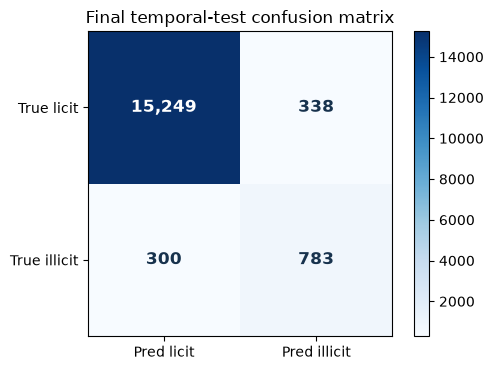

In [3]:
fig, ax = plt.subplots(figsize=(5.2,3.8)); image = ax.imshow(cm,cmap='Blues')
for (row,col),value in np.ndenumerate(cm): ax.text(col,row,f'{value:,}',ha='center',va='center',color='white' if value>cm.max()/2 else '#17324d',fontsize=12,fontweight='bold')
ax.set_xticks([0,1],['Pred licit','Pred illicit']); ax.set_yticks([0,1],['True licit','True illicit'])
ax.set_title('Final temporal-test confusion matrix'); fig.colorbar(image,ax=ax,fraction=.046); plt.tight_layout(); plt.show()

## 2. Threshold versus analyst workload

The threshold is an operational workload setting, not a cosmetic accuracy value. It was selected only on validation and then frozen for the final test.

,threshold,precision,recall,f1,reviews_per_1000
36,0.2257,0.6985,0.7230,0.7105,67.2466


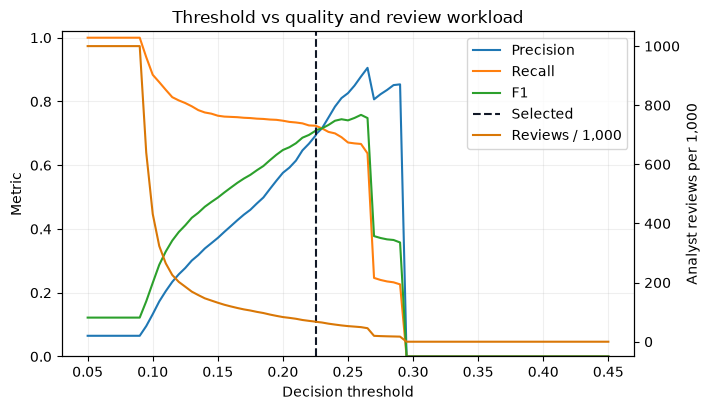

In [4]:
cuts = np.unique(np.r_[np.linspace(0.05,0.45,81),threshold]); rows=[]
for cut in cuts:
    yhat=(proba>=cut).astype(int); pp,rr,ff,_=precision_recall_fscore_support(y_true,yhat,labels=[1],average=None,zero_division=0)
    rows.append((cut,pp[0],rr[0],ff[0],1000*yhat.mean()))
frontier=pd.DataFrame(rows,columns=['threshold','precision','recall','f1','reviews_per_1000'])
display(frontier.iloc[(frontier.threshold-threshold).abs().argsort()[:1]].style.format('{:.4f}'))
fig,left=plt.subplots(figsize=(7.2,4.2))
for col in ['precision','recall','f1']: left.plot(frontier.threshold,frontier[col],label=col.title())
right=left.twinx(); right.plot(frontier.threshold,frontier.reviews_per_1000,color='#d97706',label='Reviews / 1,000')
left.axvline(threshold,color='#111827',linestyle='--',label='Selected'); left.set(xlabel='Decision threshold',ylabel='Metric',ylim=(0,1.02)); right.set_ylabel('Analyst reviews per 1,000')
lines=left.lines+right.lines; left.legend(lines,[x.get_label() for x in lines],loc='upper right'); left.grid(alpha=.2); plt.title('Threshold vs quality and review workload'); plt.tight_layout(); plt.show()

## 3. Abstention output contract

An ID outside the feature store is not converted into a zero-risk result. Inference returns `riskScore=None` and `label=unknown`; the frontend suppresses `/report`, and the API rejects a bypassed unknown report request with HTTP 422.

In [5]:
sys.path.insert(0,str(ML)); import inference as engine; engine.load()
known=engine.score_tx('70424581'); missing=engine.score_tx('999999999999')
assert known['label'] in {'illicit','licit'} and known['riskScore'] is not None
assert missing == {'txId':'999999999999','riskScore':None,'decisionThreshold':known['decisionThreshold'],'label':'unknown','topFactors':[]}
display(pd.DataFrame([known,missing])[['txId','riskScore','decisionThreshold','label']])
print('PASS: out-of-scope input receives no fabricated score.')

C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,txId,riskScore,decisionThreshold,label
0,70424581,29.0,23,illicit
1,999999999999,NaN,23,unknown


PASS: out-of-scope input receives no fabricated score.


## 4. Public deployment parity gate

This live check compares the public URL with the local model. Any mismatch means a different model or API version is deployed. A failure remains visible without aborting the notebook.

In [6]:
PUBLIC_URL='https://chaineye.onrender.com'
try:
    health=requests.get(f'{PUBLIC_URL}/health',timeout=90).json(); live=requests.post(f'{PUBLIC_URL}/score',json={'txId':'70424581'},timeout=90).json()
    same=all(live.get(k)==known.get(k) for k in ['riskScore','decisionThreshold','label'])
    display(pd.DataFrame([{'source':'local',**{k:known.get(k) for k in ['riskScore','decisionThreshold','label']}},{'source':'public',**{k:live.get(k) for k in ['riskScore','decisionThreshold','label']}}]))
    display(Markdown(('**PASS**' if same else '**FAIL - redeploy the current commit before submission.**')+f'  \nhealth: `{health}`'))
except Exception as exc: display(Markdown(f'**NETWORK CHECK SKIPPED:** `{type(exc).__name__}: {exc}`'))

,source,riskScore,decisionThreshold,label
0,local,29,23.0,illicit
1,public,96,NaN,illicit


**FAIL - redeploy the current commit before submission.**  
health: `{'status': 'ok', 'modelLoaded': True}`

## Judge-facing conclusion

- The reproducible headline is illicit-class F1 0.711 and PR-AUC 0.674 on the untouched temporal test.
- The selected threshold sends about 67 of every 1,000 test transactions to analyst review.
- Anonymous SHAP features and graph adjacency are model/data observations, not criminal evidence.
- ChainEye stops the score, report, and STR recommendation together when evidence is unavailable.
- The submission URL is acceptable only when the public deployment parity gate is PASS.